# Lab 3 — Pinta tu parcela por dentro (índices)
**Módulo 5 · Clase 3 — Índices vegetacionales e hídricos**

Vas a calcular los índices clave sobre tu parcela y **segmentarla en zonas de vigor**. Tercer commit del proyecto.

### Qué vas a hacer
1. Cargar (acceso real, **sin login**) una escena de **pico vegetativo** desde el bucket público de AWS, con las bandas necesarias.
2. Aplicar la **máscara de nubes SCL** (obligatoria).
3. Calcular **NDVI, EVI, NDRE y NDWI** y visualizarlos.
4. **Segmentar zonas de vigor** (alto/medio/bajo) conservando la variabilidad espacial.
5. Guardar los rásters de índices para las siguientes clases.

> **Acceso a datos — solo AWS.** Leemos Sentinel-2 L2A del bucket abierto `sentinel-cogs` (earth-search / Element84): sin cuenta, credenciales ni créditos. *(Las vías Copernicus openEO y Earth Engine se retiraron de este notebook.)*
>
> Recuerda la postura del módulo: el índice **localiza y prioriza**, no diagnostica. Y se lee **contra la fenología** (un mismo valor significa cosas distintas en marzo y en mayo).

In [1]:
%pip install -q pystac-client odc-stac rioxarray xarray rasterio numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Acceso anónimo al bucket público sentinel-cogs (AWS). NO requiere credenciales.
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["AWS_REGION"] = "us-west-2"
import numpy as np, matplotlib.pyplot as plt
import geopandas as gpd

# === Parámetros Ruta B: lote real en Argentina ===

aoi = gpd.read_file("data/parcela.geojson").to_crs("EPSG:4326")
BBOX = [float(x) for x in aoi.total_bounds]   # [oeste, sur, este, norte]

FECHA_INICIO = "2025-02-10"
FECHA_FIN    = "2025-03-31"
MAX_NUBES    = 30
# Bandas earth-search (entre paréntesis su nombre S2): incluye rededge1 (B05) y swir16 (B11)
BANDAS=["blue","red","rededge1","nir","swir16","scl"]   # B02, B04, B05, B08, B11, SCL
print("Pico vegetativo:", FECHA_INICIO, "->", FECHA_FIN)

Pico vegetativo: 2025-02-10 -> 2025-03-31


## 1. Cargar la escena (acceso real — earth-search / AWS, sin login)
Buscamos la escena menos nubosa del pico y la cargamos recortada a la parcela con `odc-stac` (remuestreo a 10 m). Aquí pedimos también **rededge1 (B05)** y **swir16 (B11)** para NDRE y NDWI.

In [3]:
from pystac_client import Client
from odc.stac import load as odc_load
from odc.stac import configure_rio
EARTH_SEARCH="https://earth-search.aws.element84.com/v1"

configure_rio(cloud_defaults=True, aws={"aws_unsigned": True})

def cargar():
    cat=Client.open(EARTH_SEARCH)
    items=list(cat.search(collections=["sentinel-2-l2a"], bbox=BBOX,
        datetime=f"{FECHA_INICIO}/{FECHA_FIN}",
        query={"eo:cloud_cover":{"lt":MAX_NUBES}}).items())
    if not items:
        raise RuntimeError(f"No hay escenas con nube < {MAX_NUBES}%. Sube MAX_NUBES o cambia fechas.")
    item=sorted(items, key=lambda it: it.properties["eo:cloud_cover"])[0]
    print("Escena:", item.id, "| fecha:", item.datetime.date(),
          "| nube:", item.properties["eo:cloud_cover"], "%")
    ds=odc_load([item], bands=BANDAS, bbox=BBOX, resolution=10)
    return ds.isel(time=0).to_array(dim="band")

da=cargar()
print("Cargado:", da.shape, "| bandas", [str(b) for b in da["band"].values])

Escena: S2A_20HQH_20250318_1_L2A | fecha: 2025-03-18 | nube: 0.005248 %
Cargado: (6, 119, 125) | bandas ['blue', 'red', 'rededge1', 'nir', 'swir16', 'scl']


## 2. Abrir, escalar a reflectancia y enmascarar nubes
Sentinel-2 L2A viene en enteros (0–10000). Para los índices necesitamos reflectancia [0,1] → dividimos por 10000.

> **Nota (baseline ≥ 04.00):** las escenas procesadas desde finales de 2021 traen un *offset* de −1000; el valor físico exacto es `(DN − 1000)/10000`. Para visualizar índices el `÷10000` simple basta; pon `OFFSET = -1000` si quieres la reflectancia física exacta.

Después aplicamos la máscara SCL.

In [4]:
import rioxarray  # activa el accesor .rio
OFFSET = 0   # pon -1000 para reflectancia física exacta (processing baseline >= 04.00)

def banda(n):
    return (da.sel(band=n).astype("float32") + OFFSET) / 10000.0   # reflectancia

scl = da.sel(band="scl").values
valid = np.isin(scl, [4, 5, 7])   # veg, suelo, sin-clasificar
print(f"Píxeles válidos tras SCL: {100*valid.mean():.1f}%")

B, R, RE, NIR, SWIR = banda("blue"), banda("red"), banda("rededge1"), banda("nir"), banda("swir16")

Píxeles válidos tras SCL: 100.0%


## 3. Calcular los índices
Las fórmulas son las del cheatsheet (`_support/cheatsheet-indices-vegetacion.md`). Enmascaramos los píxeles no válidos a NaN.

In [5]:
def mask(a):
    a = a.values.astype("float32"); a[~valid] = np.nan; return a

NDVI = mask((NIR-R)/(NIR+R))
EVI  = mask(2.5*(NIR-R)/(NIR+6*R-7.5*B+1))
NDRE = mask((NIR-RE)/(NIR+RE))
NDWI = mask((NIR-SWIR)/(NIR+SWIR))     # Gao: agua en la hoja

for nombre,arr in [("NDVI",NDVI),("EVI",EVI),("NDRE",NDRE),("NDWI",NDWI)]:
    print(f"{nombre}: mediana={np.nanmedian(arr):.2f}  IQR=[{np.nanpercentile(arr,25):.2f}, {np.nanpercentile(arr,75):.2f}]")

NDVI: mediana=0.89  IQR=[0.82, 0.91]
EVI: mediana=0.69  IQR=[0.56, 0.77]
NDRE: mediana=0.69  IQR=[0.57, 0.72]
NDWI: mediana=0.34  IQR=[0.25, 0.38]


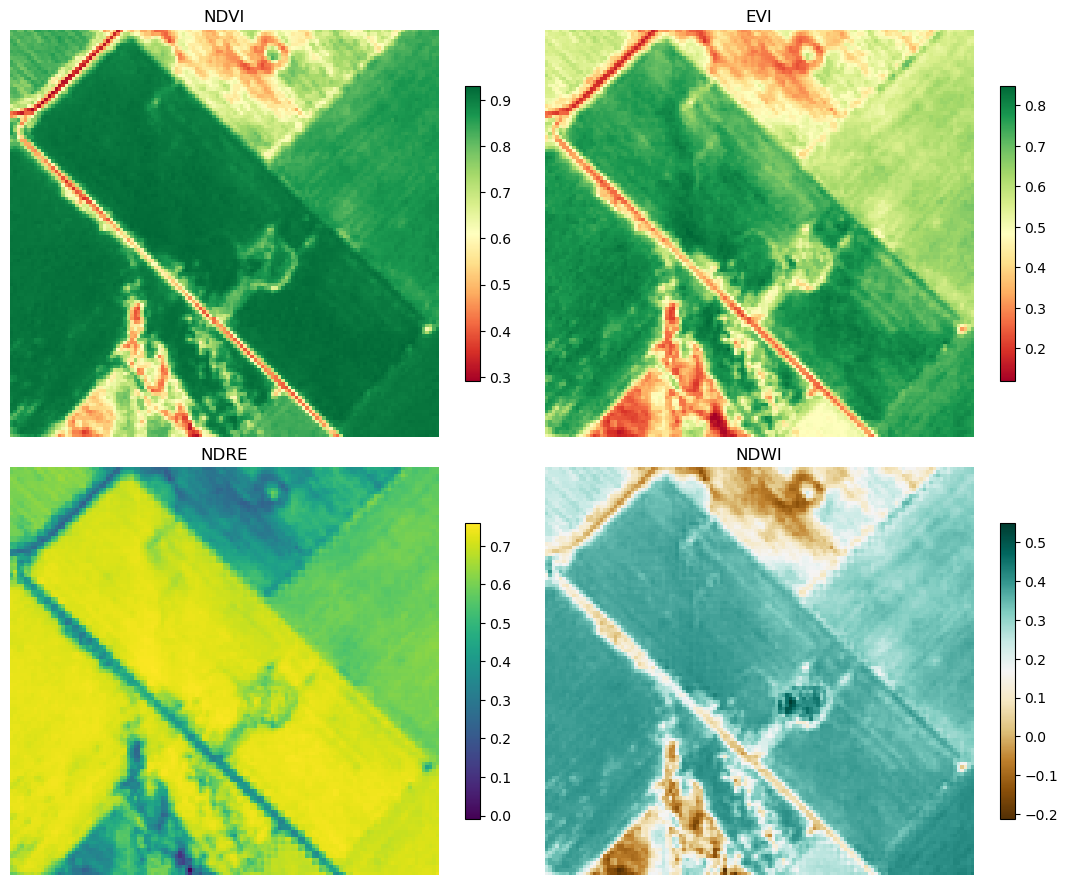

In [6]:
fig,ax=plt.subplots(2,2,figsize=(11,9))
for a,(nombre,arr,cmap) in zip(ax.ravel(),[("NDVI",NDVI,"RdYlGn"),("EVI",EVI,"RdYlGn"),("NDRE",NDRE,"viridis"),("NDWI",NDWI,"BrBG")]):
    im=a.imshow(arr,cmap=cmap); a.set_title(nombre); a.axis("off"); fig.colorbar(im,ax=a,shrink=.7)
plt.tight_layout(); plt.show()

## 4. Segmentar zonas de vigor (conserva la variabilidad)
En vez de promediar el NDVI a un número, lo dividimos en **tres zonas** por percentiles (terciles). Esto preserva la variabilidad espacial — que es justo lo que queremos gestionar.

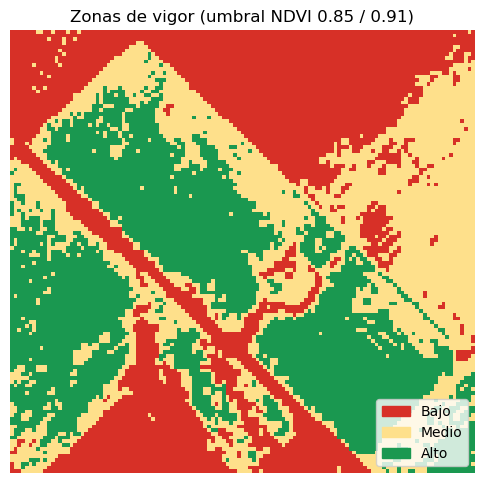

Reparto de píxeles por zona: {'bajo': 4909, 'medio': 4908, 'alto': 5058}


In [7]:
q1,q2=np.nanpercentile(NDVI,[33,66])
zonas=np.full(NDVI.shape,np.nan)
zonas[NDVI<=q1]=0; zonas[(NDVI>q1)&(NDVI<=q2)]=1; zonas[NDVI>q2]=2
import matplotlib.colors as mcolors
cmap=mcolors.ListedColormap(["#d73027","#fee08b","#1a9850"])
plt.figure(figsize=(6,6)); plt.imshow(zonas,cmap=cmap)
plt.title(f"Zonas de vigor (umbral NDVI {q1:.2f} / {q2:.2f})")
plt.axis("off")
import matplotlib.patches as mp
plt.legend(handles=[mp.Patch(color=c,label=l) for c,l in zip(["#d73027","#fee08b","#1a9850"],["Bajo","Medio","Alto"])],loc="lower right")
plt.show()
print("Reparto de píxeles por zona:", {z:int(np.nansum(zonas==i)) for i,z in enumerate(["bajo","medio","alto"])})

## 5. Guardar los rásters (para Clases 4 y 5)

In [8]:
ref = banda("nir")  # plantilla con georreferencia (DataArray float con CRS)
def guardar(nombre, arr):
    out = ref.copy(); out.values = arr
    out.rio.to_raster(f"{nombre}.tif")
for nombre,arr in [("ndvi",NDVI),("ndre",NDRE),("ndwi",NDWI)]:
    guardar(nombre, arr)
print("Guardados ndvi.tif, ndre.tif, ndwi.tif")

Guardados ndvi.tif, ndre.tif, ndwi.tif


## 6. Preguntas para entregar
1. ¿En qué zonas difieren NDVI y NDRE? ¿Qué podría significar (recuerda: el NDRE ve estrés antes)?
2. ¿El NDWI marca alguna zona con menos agua foliar? ¿Coincide con el vigor bajo del NDVI?
3. ¿Por qué segmentamos en zonas en vez de dar un NDVI medio de la parcela?
4. Sitúa la fecha de la escena en el ciclo del trigo: ¿el nivel de NDVI es coherente con esa fenología?

**Entrega:** notebook con los 4 índices + mapa de zonas + lectura agronómica. **Tercer commit.** Antes de la Clase 4 (23/06).

¿En que zonas difieren NDVI y NDRE? ¿Qué podría significar (recuerda: el NDRE ve estré antes)?
El NDVI muestra un vigor vegetativo elevado en gran parte de la parcela, con valores cercanos a 0,9 en las zonas más desarrolladas. Sin embargo, el NDRE evidencia variaciones internas que no son tan visibles en el NDVI, especialmente en sectores donde la vegetación presenta una ligera disminuición de vigor. Esto puede indicar un stress fisiológico incipiente o diferencias en el contenido de clorofila, ya que el NDRE es más sensible que el NDVI para detectar cambios tempranos en cultivos con alta cobrtura vegetal.

¿El NDWI marca alguna zona con menos agua foliar?¿Concide con el vigor bajo del NDVI?
El NDWI identifica sectores con menos contenido de agua foliar, principalmente en los brdes del lote y en algunas áreas nternas donde los valores disminuyen respecto al resto del cultivo. Estas zonas presentan una correspondencia parcial con los sectores de menor vigor obsevados en el NDVI, lo que sugiere que parte de la variabilidad detectada podría estar asociada a diferencias en la disponibilidad hídrica o al estado fisiológco de las plantas.

¿Por qué segmentamos en zonas en vez de dar un NDVI medio de la parcela?
Un único valor promedio de NDVI ocultaría la variabilidad espacial presente dentro de la parcela. La segmentación permite identificar zonas de alto, medio y bajo vigor, facilitando la aplicación de estrartegias de manejo específicas para cada sector, como fertilización variable, monitoreo dirigido o inspecciones a campo. Este enfoque constituye la base de la agricultura de precisión.

Sitúa la fecha de la escena en el ciclo del trigo: el nivel de NDVI es coherente con esa fenología?
Aunque el laboratorio está planteado para un cultivo de trigo, este trabajo fue adaptado a una parcela real, correspondiente a un cultivo de soja de segunda en Argentina. La escena seleccionada corresponde al 18 de marzo de 2025, período cercano al máximo desarrollo vegetativo del cultivo. Los elevados valores de NDVI observados son coherentes con esta etapa fenológica, ya que reflejan una elevada cobertura vegetal y una intensa actividad fotosintética previa al inicio del proceso de maduración.